# Final Project - C&S BIO M178

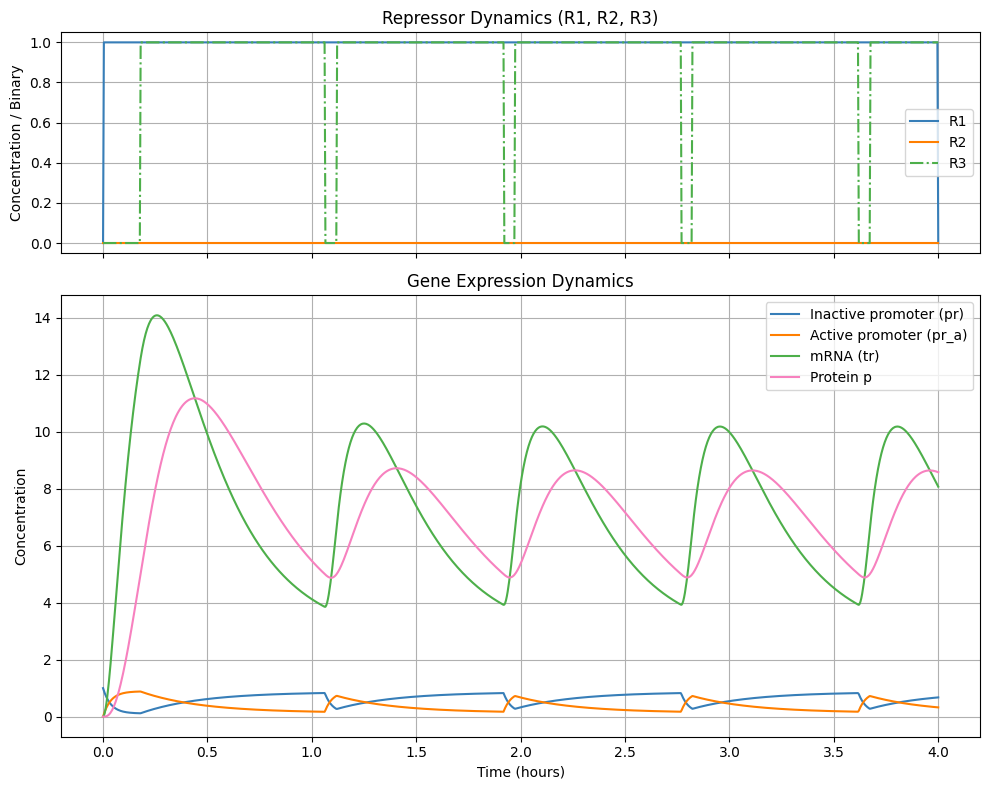

In [ ]:
# Import all of the packages
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Color cycle
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_color_cycle)


# Two-repressor gene expression model with protein feedback (R1 AND (R2 OR R3))
def repression_model(states, t):
    pr, pr_a, tr, p = states

    # R1 dynamics (exactly like HW6)
    R1 = R1_amp if R1_on < t < R1_off else 0

    # R2 dynamics (like HW6)
    R2 = R2_amp if R2_on < t < R2_off else 0
    
    # R3 dynamics based on threshold
    R3 = R3_amp if p > p_threshold else 0

    # Hill functions for each repressor 
    H1 = R1 / (R1 + Kd1)
    H2 = R2 / (R2 + Kd2)
    H3 = R3 / (R3 + Kd3)

    # Logic gate: Expression ON when NOT (R1 AND (R2 OR R3))
    H = 1 - H1 * (1 - (1 - H2) * (1 - H3))

    # ODEs
    pr_prime = -k_a * H * pr + k_d * pr_a
    pr_a_prime = k_a * H * pr - k_d * pr_a
    tr_prime = k_syn * pr_a - k_deg * tr
    p_prime = k_trans * tr - k_pdeg * p

    return [pr_prime, pr_a_prime, tr_prime, p_prime]


# Initial conditions
states0 = [1, 0, 0, 0]  # pr, pr_a, tr, p

# Parameters
k_a = 0.4      # promoter activation rate
k_d = 0.05     # promoter deactivation rate
Kd1 = 0.01    # repression by R1
Kd2 = 0.01    # repression by R2
Kd3 = 0.01    # repression by R3

k_syn = 3      # transcription rate
k_deg = 0.15   # mRNA degradation
k_trans = 0.1  # translation rate
k_pdeg = 0.1   # protein degradation rate

# R1 dynamics
R1_amp = 1
R1_on = 0
R1_off = 240

# R2 dynamics
R2_amp = 0
R2_on = 120
R2_off = 180

R3_amp = 1           # amplitude of binary repressor R3 (if 0, R3 is nonfunctional)
p_threshold = 5         # threshold for switching R3 ON

# Time span
t = np.linspace(0, 240, 1000)

# Solve ODEs
solution = odeint(repression_model, states0, t)

# Compute R1, R2, R3 for plotting
R1_vals = np.array([R1_amp if R1_on < ti < R1_off else 0 for ti in t])
R2_vals = np.array([R2_amp if R2_on < ti < R2_off else 0 for ti in t])
R3_vals = np.array([R3_amp if solution[i,3] > p_threshold else 0 for i in range(len(t))])

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8), sharex=True, gridspec_kw={'height_ratios':[1,2]})

# Plot repressors
ax1.plot(t/60, R1_vals, label='R1')
ax1.plot(t/60, R2_vals, label='R2')
ax1.plot(t/60, R3_vals, label='R3', linestyle='-.')
ax1.set_ylabel('Concentration / Binary')
ax1.set_title('Repressor Dynamics (R1, R2, R3)')
ax1.legend()
ax1.grid(True)

# Plot gene expression
ax2.plot(t/60, solution[:,0], label='Inactive promoter (pr)')
ax2.plot(t/60, solution[:,1], label='Active promoter (pr_a)')
ax2.plot(t/60, solution[:,2], label='mRNA (tr)')
ax2.plot(t/60, solution[:,3], label='Protein p')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Concentration')
ax2.set_title('Gene Expression Dynamics')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



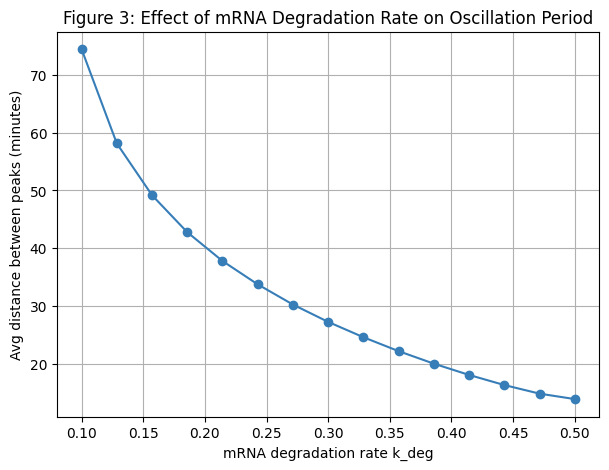

In [3]:
# k_deg (mRNA degradation rate) Parameter SWEEP - Distance Between Peaks (ignore first peak)

# Returns the average distance between peaks of a time-series signal, ignoring the first peak

def get_peak_distances(signal, tvec):
    from scipy.signal import find_peaks
    
    peaks, _ = find_peaks(signal)
    
    # ignore first peak
    peaks = peaks[1:]
    
    if len(peaks) < 2:
        return np.nan  # insufficient peaks for oscillations
    
    distances = np.diff(tvec[peaks])
    return np.mean(distances)

# Linear sweep of mRNA degradation rate
k_deg_values = np.linspace(0.1, 0.5, 15)
peak_distances = []

for kd in k_deg_values:
    k_deg = kd  # override mRNA degradation rate
    
    sol = odeint(repression_model, states0, t)
    protein_trace = sol[:, 3]
    
    dist = get_peak_distances(protein_trace, t)
    peak_distances.append(dist)

# Replace NaN values with 0
peak_distances = [0 if np.isnan(d) else d for d in peak_distances]

# Plot the k_deg Sweep (Distance Between Peaks)
plt.figure(figsize=(7,5))
plt.plot(k_deg_values, peak_distances, marker='o')
plt.xlabel("mRNA degradation rate k_deg")
plt.ylabel("Avg distance between peaks (minutes)")
plt.title("Figure 3: Effect of mRNA Degradation Rate on Oscillation Period")
plt.grid(True)
plt.show()


In [4]:
# Reset Parameters to Original Values

k_a = 0.4      # promoter activation rate
k_d = 0.05     # promoter deactivation rate
Kd1 = 0.01    # repression by R1
Kd2 = 0.01    # repression by R2
Kd3 = 0.01    # repression by R3

k_syn = 3      # transcription rate
k_deg = 0.15   # mRNA degradation
k_trans = 0.1  # translation rate
k_pdeg = 0.1   # protein degradation rate

# R1 dynamics
R1_amp = 1
R1_on = 0
R1_off = 240

# R2 dynamics
R2_amp = 0
R2_on = 120
R2_off = 180

R3_amp = 1           # amplitude of binary repressor R3 (if 0, R3 is nonfunctional)
p_threshold = 5         # threshold for switching R3 ON


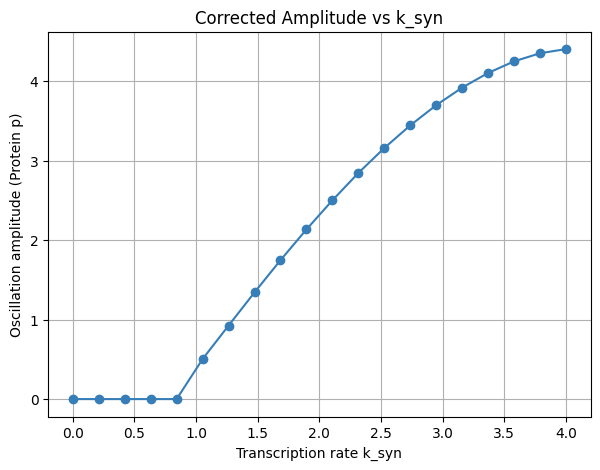

In [6]:
# k_syn parameter sweet - plotting oscillation amplitude
from scipy.signal import find_peaks

# Oscillation amplitude detection (ignoring first peak)
def get_oscillation_amplitude(signal, time_fraction=0.5, noise_floor=0.05):

    # Keep only last half of trajectory (steady state region)
    n = int(len(signal) * time_fraction)
    steady = signal[n:]

    # Detect peaks and troughs
    peaks, _ = find_peaks(steady)
    troughs, _ = find_peaks(-steady)

    # Need at least one peak and trough
    if len(peaks) < 1 or len(troughs) < 1:
        return 0

    amplitude = steady[peaks].max() - steady[troughs].min()

    # Remove numerical noise
    if amplitude < noise_floor:
        return 0

    return amplitude


# Sweep range
k_syn_values = np.linspace(0, 4, 20)
amplitudes = []

for ks in k_syn_values:
    k_syn = ks  # override transcription rate
    sol = odeint(repression_model, states0, t)
    p_trace = sol[:, 3]  # protein
    amp = get_oscillation_amplitude(p_trace)
    amplitudes.append(amp)

# Plot
plt.figure(figsize=(7,5))
plt.plot(k_syn_values, amplitudes, marker='o')
plt.xlabel("Transcription rate k_syn")
plt.ylabel("Oscillation amplitude (Protein p)")
plt.title("Corrected Amplitude vs k_syn")
plt.grid(True)
plt.show()


In [7]:
# Reset Parameters to Original Values

k_a = 0.4      # promoter activation rate
k_d = 0.05     # promoter deactivation rate
Kd1 = 0.01    # repression by R1
Kd2 = 0.01    # repression by R2
Kd3 = 0.01    # repression by R3

k_syn = 3      # transcription rate
k_deg = 0.15   # mRNA degradation
k_trans = 0.1  # translation rate
k_pdeg = 0.1   # protein degradation rate

# R1 dynamics
R1_amp = 1
R1_on = 0
R1_off = 240

# R2 dynamics
R2_amp = 0
R2_on = 120
R2_off = 180

R3_amp = 1           # amplitude of binary repressor R3 (if 0, R3 is nonfunctional)
p_threshold = 5         # threshold for switching R3 ON


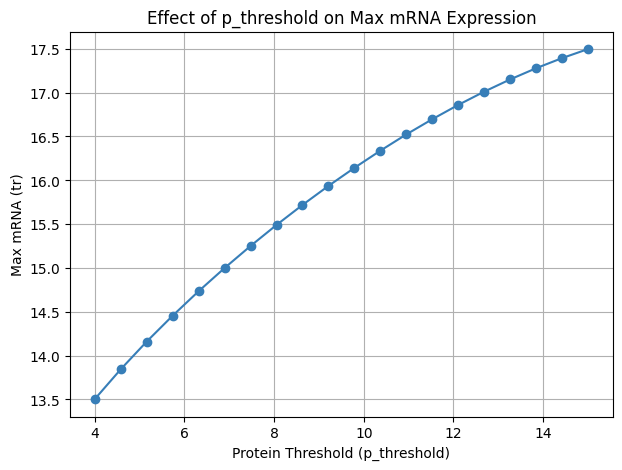

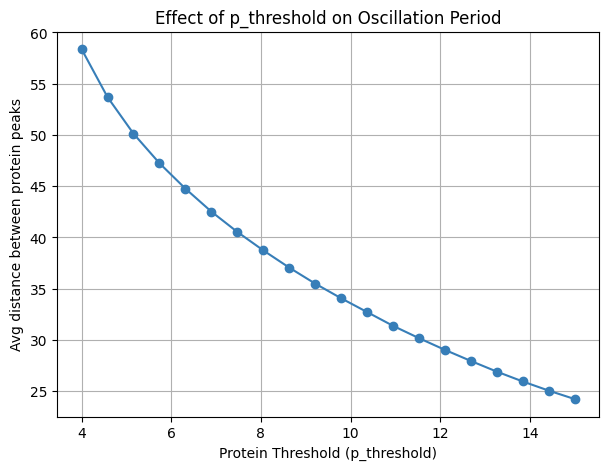

In [8]:
# Threshold parameter sweep

# Reuse peak distance
def get_peak_distances(signal, tvec):
    from scipy.signal import find_peaks
    
    peaks, _ = find_peaks(signal)
    
    # ignore first peak
    peaks = peaks[1:]
    
    if len(peaks) < 2:
        return np.nan  # insufficient peaks for oscillations
    
    distances = np.diff(tvec[peaks])
    return np.mean(distances)


threshold_values = np.linspace(4, 15, 20)
max_mRNA = []
peak_distances = []

for p_thresh in threshold_values:
    p_threshold = p_thresh  # update global threshold
    
    sol = odeint(repression_model, states0, t)
    tr_trace = sol[:, 2]
    p_trace = sol[:, 3]
    
    # Max mRNA
    max_mRNA.append(np.max(tr_trace))
    
    # Distance between protein peaks
    dist = get_peak_distances(p_trace, t)
    peak_distances.append(dist if not np.isnan(dist) else 0)

# Plot 1: Max mRNA vs Threshold
plt.figure(figsize=(7,5))
plt.plot(threshold_values, max_mRNA, marker='o')
plt.xlabel("Protein Threshold (p_threshold)")
plt.ylabel("Max mRNA (tr)")
plt.title("Effect of p_threshold on Max mRNA Expression")
plt.grid(True)
plt.show()

# Plot 2: Avg distance between protein peaks vs Threshold
plt.figure(figsize=(7,5))
plt.plot(threshold_values, peak_distances, marker='o')
plt.xlabel("Protein Threshold (p_threshold)")
plt.ylabel("Avg distance between protein peaks")
plt.title("Effect of p_threshold on Oscillation Period")
plt.grid(True)
plt.show()
